# DS2002 · SQL to Python to DataFrames

**Lecture — 2026-09-14 · Fall 2026**  
**Class time:** 45 minutes

---

## What Pandas is

Pandas is a Python library that gives Python something it does not have on its own: a **table**.

By itself, Python has lists and dictionaries. Read a CSV with plain Python and you get a list of rows where every value is a string. Nothing knows that `price` is a number, that `qty` is a count, or that `vendor_id` in one file points at `vendor_id` in another. Every question you want to ask — total revenue, revenue by category, revenue with vendor names attached — becomes a loop you write and debug yourself.

Pandas replaces all of that with two objects:

- A **DataFrame** is the whole table: rows, named columns, one data type per column. It is the same thing you already know as a SQL table or a spreadsheet tab, except it lives in your program's memory and you drive it with code.
- A **Series** is one column, with its row labels attached.

Nearly everything you do for the rest of the semester is a method on one of those two.

**Why we use it.** Three reasons, in the order you will feel them:

1. **Operations apply to a whole column at once.** No loop, no type conversion by hand.
2. **The hard parts are already written.** Missing values, duplicate rows, type conversion, grouping, joining — one call each, and they behave the same way every time.
3. **It is what everything else expects.** Charting libraries, scikit-learn, and the report you hand somebody all take a DataFrame. It is the standard shape of data in Python.

In this course, Pandas is the layer in the middle: you pull data out of a database or an API, you clean and reshape it in a DataFrame, and then you chart it or model it.

*(The name is short for “panel data,” a term from econometrics. It is one library, singular, even though the name sounds plural.)*

The next cell sets up drawing helpers for the diagrams in this lecture. It is scaffolding — none of it is Pandas you need to learn. Run it and move on.

In [4]:
# Drawing helpers for the diagrams in this lecture. Scaffolding only --
# nothing here is pandas you need to learn.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

TINT = {'Food': '#cfe2f3', 'Merch': '#fce5cd', 'RainGear': '#d9ead3',
        'Drink': '#ead1dc', 'ok': '#d9ead3', 'bad': '#f7c6c6'}
RED = '#b22222'

def panel(ax, xlim=12, ylim=9):
    ax.set_xlim(0, xlim); ax.set_ylim(0, ylim); ax.axis('off')

def box(ax, x, y, w, h, text, face='white', edge='0.3', fs=9, bold=False,
        dashed=False, family='sans-serif'):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=face, edgecolor=edge, lw=1.4,
                           linestyle='--' if dashed else '-', zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=fs,
            fontweight='bold' if bold else 'normal', family=family, zorder=3)

def arrow(ax, start, end, color='0.45', lw=1.4, dashed=False, scale=13):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=scale,
                                 color=color, lw=lw, linestyle='--' if dashed else '-',
                                 shrinkA=2, shrinkB=2))

print('diagram helpers ready')

diagram helpers ready


Here is the whole argument for the library in one picture. Same three order lines, same question — what is the total revenue?

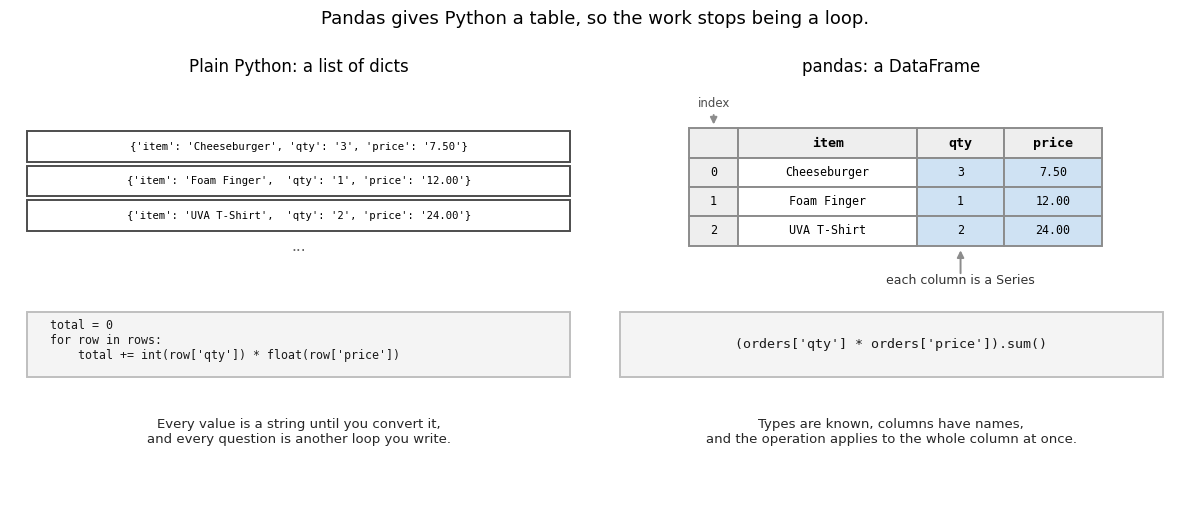

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))

# -- left: what plain Python hands you
ax = axes[0]
panel(ax, 10, 10)
ax.set_title('Plain Python: a list of dicts', fontsize=12, pad=12)
raw = ["{'item': 'Cheeseburger', 'qty': '3', 'price': '7.50'}",
       "{'item': 'Foam Finger',  'qty': '1', 'price': '12.00'}",
       "{'item': 'UVA T-Shirt',  'qty': '2', 'price': '24.00'}"]
for i, r in enumerate(raw):
    box(ax, 0.3, 8.2 - i * 0.85, 9.4, 0.75, r, fs=7.6, family='monospace')
ax.text(5.0, 6.0, '...', ha='center', fontsize=11, color='0.4')
box(ax, 0.3, 2.9, 9.4, 1.6, '', face='#f4f4f4', edge='0.75')
ax.text(0.7, 4.32, "total = 0\nfor row in rows:\n"
                   "    total += int(row['qty']) * float(row['price'])",
        ha='left', va='top', fontsize=8.4, family='monospace', color='0.1')
ax.text(5.0, 1.9, 'Every value is a string until you convert it,\n'
                  'and every question is another loop you write.',
        ha='center', va='top', fontsize=9.5, color='0.15')

# -- right: what pandas hands you
ax = axes[1]
panel(ax, 10, 10)
ax.set_title('pandas: a DataFrame', fontsize=12, pad=12)
X0, GUT = 1.5, 0.85
cols = [('item', 3.1, 'white'), ('qty', 1.5, TINT['Food']), ('price', 1.7, TINT['Food'])]
data = [('Cheeseburger', '3', '7.50'), ('Foam Finger', '1', '12.00'),
        ('UVA T-Shirt', '2', '24.00')]
box(ax, X0, 8.3, GUT, 0.72, '', face='#eeeeee', edge='0.55')
x = X0 + GUT
for name, w, _ in cols:
    box(ax, x, 8.3, w, 0.72, name, face='#eeeeee', edge='0.55', fs=9.5, bold=True,
        family='monospace')
    x += w
for i, rowvals in enumerate(data):
    y = 7.58 - i * 0.72
    box(ax, X0, y, GUT, 0.72, str(i), face='#eeeeee', edge='0.55', fs=8.5,
        family='monospace')
    x = X0 + GUT
    for (name, w, tint), val in zip(cols, rowvals):
        box(ax, x, y, w, 0.72, val, face=tint, edge='0.55', fs=8.4, family='monospace')
        x += w
bottom = 7.58 - 2 * 0.72
ax.text(X0 + GUT / 2, 9.55, 'index', ha='center', fontsize=8.5, color='0.3')
arrow(ax, (X0 + GUT / 2, 9.42), (X0 + GUT / 2, 9.05), color='0.55', scale=10)
ax.text(X0 + GUT + 3.85, bottom - 0.95, 'each column is a Series',
        ha='center', fontsize=9, color='0.2')
arrow(ax, (X0 + GUT + 3.85, bottom - 0.75), (X0 + GUT + 3.85, bottom - 0.05),
      color='0.55', scale=10)
box(ax, 0.3, 2.9, 9.4, 1.6, '', face='#f4f4f4', edge='0.75')
ax.text(5.0, 3.70, "(orders['qty'] * orders['price']).sum()",
        ha='center', va='center', fontsize=9.6, family='monospace', color='0.1')
ax.text(5.0, 1.9, 'Types are known, columns have names,\n'
                  'and the operation applies to the whole column at once.',
        ha='center', va='top', fontsize=9.5, color='0.15')

fig.suptitle('Pandas gives Python a table, so the work stops being a loop.',
             fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

## The same operations, a different tool

You spent last week describing results in SQL. Today you do the same work in Pandas, and the fair question is why bother learning both.

Use **SQL** when the data already lives in a database, when it is too big to fit in memory, or when someone else needs to run your query. Use **Pandas** when the data arrives as files, when you need to reshape it repeatedly while you figure out what you are looking at, or when the next step is a chart or a model.

Most real pipelines use both: SQL to pull a manageable slice, Pandas to work it. Here is the translation table — pin it somewhere.

| SQL | Pandas |
|---|---|
| `SELECT a, b FROM t` | `df[['a', 'b']]` |
| `WHERE qty > 2` | `df[df['qty'] > 2]` |
| `WHERE a > 2 AND b = 'x'` | `df[(df['a'] > 2) & (df['b'] == 'x')]` |
| `ORDER BY qty DESC` | `df.sort_values('qty', ascending=False)` |
| `GROUP BY cat` + `SUM(x)` | `df.groupby('cat')['x'].sum()` |
| `HAVING SUM(x) > 100` | `.loc[lambda s: s > 100]` after the groupby |
| `JOIN ... ON a.id = b.id` | `a.merge(b, on='id')` |
| `COUNT(DISTINCT u)` | `df['u'].nunique()` |
| `LIMIT 5` | `df.head(5)` |

### The data

Two files, the way you would actually get them: order lines from the point-of-sale system, and a vendor list from somebody's spreadsheet.

In [6]:
import pandas as pd
from io import StringIO

orders = pd.read_csv(StringIO('''order_id,vendor_id,category,item,qty,price
1001,V-01,Food,Cheeseburger,3,7.50
1002,V-10,Merch,Foam Finger,1,12.00
1003,V-10,Merch,UVA T-Shirt,2,24.00
1004,V-05,Food,Chicken Tacos,4,6.50
1005,V-18,RainGear,Rain Poncho,10,6.00
1006,V-01,Food,Hot Dog,2,4.50
1007,V-99,Drink,Bottled Water,6,3.00'''))

vendors = pd.read_csv(StringIO('''vendor_id,vendor_name,zone
V-01,Hoos Burgers,A
V-05,Rotunda Tacos,B
V-10,Cav Merch North,A
V-18,Rally Rain Gear,C'''))

print(orders.shape, vendors.shape)
orders

(7, 6) (4, 3)


,order_id,vendor_id,category,item,qty,price
0,1001,V-01,Food,Cheeseburger,3,7.5
1,1002,V-10,Merch,Foam Finger,1,12.0
2,1003,V-10,Merch,UVA T-Shirt,2,24.0
3,1004,V-05,Food,Chicken Tacos,4,6.5
4,1005,V-18,RainGear,Rain Poncho,10,6.0
5,1006,V-01,Food,Hot Dog,2,4.5
6,1007,V-99,Drink,Bottled Water,6,3.0


### Look before you work

`.info()` is the Pandas equivalent of reading the schema. It tells you the row count, the column types, and how many non-null values each column has — three things that will explain most errors you are about to hit.

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   order_id   7 non-null      int64  
 1   vendor_id  7 non-null      object 
 2   category   7 non-null      object 
 3   item       7 non-null      object 
 4   qty        7 non-null      int64  
 5   price      7 non-null      float64
dtypes: float64(1), int64(2), object(3)
memory usage: 468.0+ bytes


### Selecting and filtering

One bracket gives you a Series; two brackets give you a DataFrame. That distinction matters as soon as you start chaining operations.

In [8]:
print(type(orders['item']))          # Series -- one column
print(type(orders[['item', 'qty']])) # DataFrame -- a table

orders[orders['category'] == 'Food'][['item', 'qty', 'price']]

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,item,qty,price
0,Cheeseburger,3,7.5
3,Chicken Tacos,4,6.5
5,Hot Dog,2,4.5


Combining conditions in Pandas needs `&` and `|`, not `and` and `or`, and every condition needs its own parentheses. Forgetting either produces one of the least helpful error messages in Python.

In [9]:
orders[(orders['qty'] >= 3) & (orders['price'] < 10)]

,order_id,vendor_id,category,item,qty,price
0,1001,V-01,Food,Cheeseburger,3,7.5
3,1004,V-05,Food,Chicken Tacos,4,6.5
4,1005,V-18,RainGear,Rain Poncho,10,6.0
6,1007,V-99,Drink,Bottled Water,6,3.0


### Derived columns and the copy warning

Adding a column is straightforward. What trips people up is adding one to a **slice**.

In [10]:
orders['revenue'] = orders['qty'] * orders['price']
orders[['order_id', 'item', 'qty', 'price', 'revenue']]

,order_id,item,qty,price,revenue
0,1001,Cheeseburger,3,7.5,22.5
1,1002,Foam Finger,1,12.0,12.0
2,1003,UVA T-Shirt,2,24.0,48.0
3,1004,Chicken Tacos,4,6.5,26.0
4,1005,Rain Poncho,10,6.0,60.0
5,1006,Hot Dog,2,4.5,9.0
6,1007,Bottled Water,6,3.0,18.0


Now the mistake. This looks reasonable and pandas will warn you about it:

```python
food = orders[orders['category'] == 'Food']
food['discounted'] = food['revenue'] * 0.9      # SettingWithCopyWarning
```

The slice may be a view onto the original, so pandas cannot promise where your assignment lands. The fix is one word — `.copy()` — and it should become reflex whenever you filter and then modify.

In [11]:
food = orders[orders['category'] == 'Food'].copy()
food['discounted'] = (food['revenue'] * 0.9).round(2)
food[['item', 'revenue', 'discounted']]

,item,revenue,discounted
0,Cheeseburger,22.5,20.25
3,Chicken Tacos,26.0,23.40
5,Hot Dog,9.0,8.10


Here is what the warning is actually about. On the left, `food` may be a window onto `orders`, so pandas cannot tell you where your assignment will land. On the right, `.copy()` has made `food` a frame of its own.

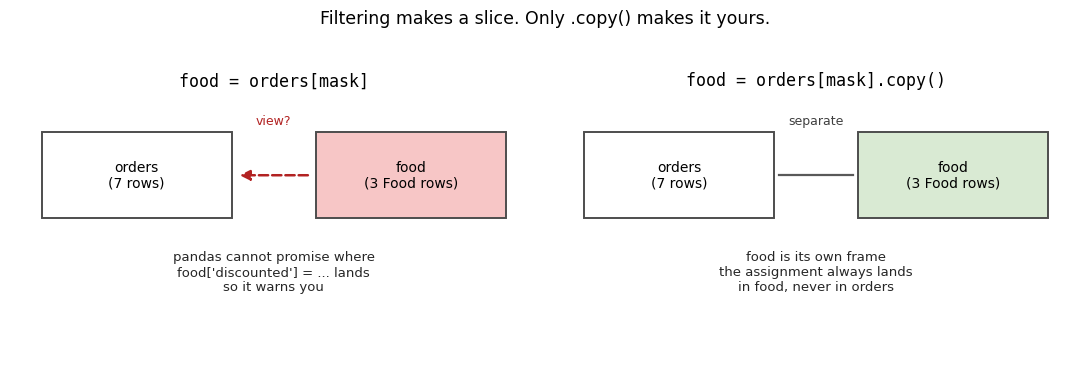

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, title, tint, note in [
    (axes[0], 'food = orders[mask]', TINT['bad'],
     "pandas cannot promise where\nfood['discounted'] = ... lands\nso it warns you"),
    (axes[1], 'food = orders[mask].copy()', TINT['ok'],
     'food is its own frame\nthe assignment always lands\nin food, never in orders'),
]:
    panel(ax, 10, 10)
    ax.set_title(title, fontsize=12, family='monospace', pad=10)
    box(ax, 0.6, 5.6, 3.6, 3.2, 'orders\n(7 rows)', fs=10)
    box(ax, 5.8, 5.6, 3.6, 3.2, 'food\n(3 Food rows)', face=tint, fs=10)
    if 'copy' in title:
        ax.plot([4.3, 5.7], [7.2, 7.2], color='0.35', lw=1.6)
        ax.text(5.0, 9.1, 'separate', ha='center', fontsize=9, color='0.25')
    else:
        arrow(ax, (5.7, 7.2), (4.3, 7.2), color=RED, lw=1.8, dashed=True, scale=15)
        ax.text(5.0, 9.1, 'view?', ha='center', fontsize=9, color=RED)
    ax.text(5.0, 4.4, note, ha='center', va='top', fontsize=9.5, color='0.15')
fig.suptitle('Filtering makes a slice. Only .copy() makes it yours.', fontsize=12.5, y=1.04)
fig.tight_layout()
plt.show()

### Grouping

`groupby` splits rows into buckets, applies a function, and puts the answers back together. This is `GROUP BY` with more flexibility about what comes next.

Those three words are the whole mechanism, so it is worth seeing them happen once before you read the one-liner that does them.

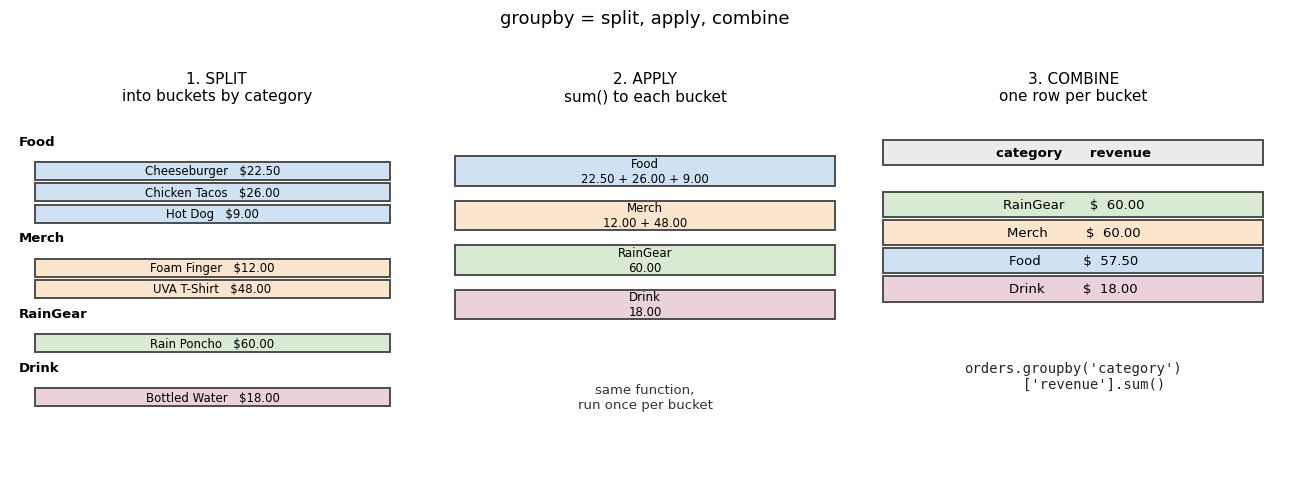

In [13]:
cats = ['Food', 'Merch', 'RainGear', 'Drink']
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, t in zip(axes, ['1. SPLIT\ninto buckets by category',
                        '2. APPLY\nsum() to each bucket',
                        '3. COMBINE\none row per bucket']):
    panel(ax, 10, 12)
    ax.set_title(t, fontsize=11, pad=8)

y = 11.0
for c in cats:
    axes[0].text(0.2, y, c, fontsize=9.5, fontweight='bold', va='center')
    y -= 0.75
    for _, r in orders[orders['category'] == c].iterrows():
        box(axes[0], 0.6, y - 0.55, 8.6, 0.6,
            f"{r['item']}   ${r['revenue']:.2f}", face=TINT[c], fs=8.5)
        y -= 0.72
    y -= 0.35

y = 10.4
for c in cats:
    vals = orders.loc[orders['category'] == c, 'revenue']
    box(axes[1], 0.4, y - 0.9, 9.2, 1.0,
        f'{c}\n' + ' + '.join(f'{v:.2f}' for v in vals), face=TINT[c], fs=8.5)
    y -= 1.5
axes[1].text(5.0, 2.0, 'same function,\nrun once per bucket',
             ha='center', fontsize=9.5, color='0.2')

res = orders.groupby('category')['revenue'].sum().sort_values(ascending=False)
box(axes[2], 0.4, 10.2, 9.2, 0.85, 'category      revenue', face='0.92', fs=9.5, bold=True)
y = 9.3
for c, v in res.items():
    box(axes[2], 0.4, y - 0.85, 9.2, 0.85, f'{c:<12}  ${v:>7.2f}', face=TINT[c], fs=9.5)
    y -= 0.95
axes[2].text(5.0, 3.6, "orders.groupby('category')\n     ['revenue'].sum()",
             ha='center', va='top', fontsize=10, family='monospace', color='0.15')

fig.suptitle('groupby = split, apply, combine', fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

In [14]:
orders.groupby('category')['revenue'].sum().sort_values(ascending=False)

,revenue
category,
RainGear,60.0
Merch,60.0
Food,57.5
Drink,18.0


You will often want several summaries at once. `.agg()` takes a dict of `new_name=(column, function)` pairs, which keeps the result readable.

In [15]:
orders.groupby('category').agg(
    orders=('order_id', 'count'),
    units=('qty', 'sum'),
    revenue=('revenue', 'sum'),
    avg_ticket=('revenue', 'mean'),
).round(2)

,orders,units,revenue,avg_ticket
category,,,,
Drink,1,6,18.0,18.00
Food,3,9,57.5,19.17
Merch,2,3,60.0,30.00
RainGear,1,10,60.0,60.00


### Joining, and checking that the join worked

Here is the move Monday's SQL lecture spent all week building toward, in Pandas. `orders` has a `vendor_id`; the names live in `vendors`.

Note `how='left'` and `indicator=True`. The indicator column tells you, row by row, whether the match succeeded — which is how you catch a silent data problem instead of shipping it.

In [16]:
joined = orders.merge(vendors, on='vendor_id', how='left', indicator=True)
print('rows before:', len(orders), '| rows after:', len(joined))
print()
print(joined['_merge'].value_counts())
joined[['order_id', 'vendor_id', 'vendor_name', 'zone', 'revenue', '_merge']]

rows before: 7 | rows after: 7

_merge
both          6
left_only     1
right_only    0
Name: count, dtype: int64


,order_id,vendor_id,vendor_name,zone,revenue,_merge
0,1001,V-01,Hoos Burgers,A,22.5,both
1,1002,V-10,Cav Merch North,A,12.0,both
2,1003,V-10,Cav Merch North,A,48.0,both
3,1004,V-05,Rotunda Tacos,B,26.0,both
4,1005,V-18,Rally Rain Gear,C,60.0,both
5,1006,V-01,Hoos Burgers,A,9.0,both
6,1007,V-99,NaN,NaN,18.0,left_only


Seven rows in, seven rows out, but one of them did not match: vendor `V-99` is in the orders and not in the vendor list. Its `vendor_name` and `zone` are `NaN`.

That is a real finding, not a nuisance. Somebody sold six bottles of water and the vendor roster does not know who they are. If you had used `how='inner'` you would have quietly dropped eighteen dollars and never known.

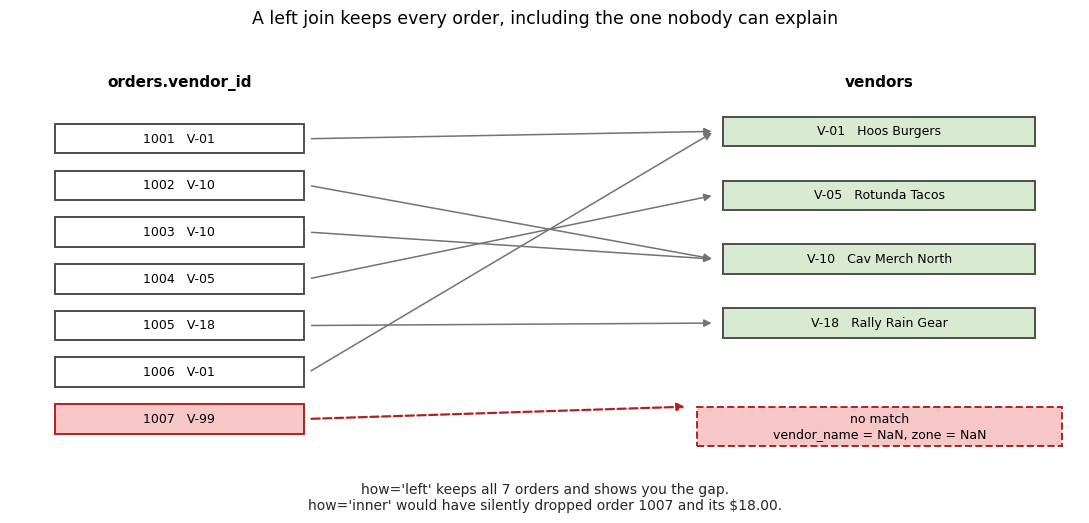

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.2))
panel(ax, 12, 9)
vend_y = {'V-01': 7.2, 'V-05': 5.9, 'V-10': 4.6, 'V-18': 3.3}
names = dict(zip(vendors['vendor_id'], vendors['vendor_name']))

ax.text(1.9, 8.4, 'orders.vendor_id', ha='center', fontsize=11, fontweight='bold')
ax.text(9.75, 8.4, 'vendors', ha='center', fontsize=11, fontweight='bold')

y = 7.6
for _, r in orders.iterrows():
    vid = r['vendor_id']
    hit = vid in vend_y
    box(ax, 0.5, y - 0.55, 2.8, 0.6, f"{r['order_id']}   {vid}",
        face='white' if hit else TINT['bad'], edge='0.3' if hit else RED, fs=9)
    if hit:
        arrow(ax, (3.35, y - 0.25), (7.9, vend_y[vid] + 0.3), lw=1.1, scale=11)
    else:
        arrow(ax, (3.35, y - 0.25), (7.6, 1.9), color=RED, lw=1.6, dashed=True, scale=11)
    y -= 0.95

for vid, vy in vend_y.items():
    box(ax, 8.0, vy, 3.5, 0.6, f'{vid}   {names[vid]}', face=TINT['ok'], fs=9)
box(ax, 7.7, 1.1, 4.1, 0.8, 'no match\nvendor_name = NaN, zone = NaN',
    face=TINT['bad'], edge=RED, fs=9, dashed=True)

ax.text(6.0, 0.35,
        "how='left' keeps all 7 orders and shows you the gap.\n"
        "how='inner' would have silently dropped order 1007 and its $18.00.",
        ha='center', va='top', fontsize=10, color='0.15')
fig.suptitle('A left join keeps every order, including the one nobody can explain',
             fontsize=12.5, y=1.0)
fig.tight_layout()
plt.show()

In [18]:
unmatched = joined[joined['_merge'] == 'left_only']
print('orders with no known vendor:', len(unmatched))
print('revenue at stake: $', unmatched['revenue'].sum(), sep='')

orders with no known vendor: 1
revenue at stake: $18.0


### The three questions to ask after every merge

1. **Did the row count change the way I expected?** More rows than you started with means your join key is not unique on one side and rows got duplicated.
2. **Did anything fail to match?** `indicator=True`, then look at `_merge`.
3. **Are the totals still right?** Sum a money column before and after. If it moved, the join did something you did not ask for.

You will do exactly this on the midterm when you join sales to weather, and on the capstone when you join orders to vendors. Practicing it on seven rows is much cheaper than debugging it on a hundred thousand.

In [19]:
# The duplication trap, in miniature: a vendor list with a repeated id
dupes = pd.concat([vendors, vendors.iloc[[0]]], ignore_index=True)
bad = orders.merge(dupes, on='vendor_id', how='left')
print('orders:', len(orders), '-> after joining a list with a duplicate id:', len(bad))
print('revenue before: $', orders['revenue'].sum(), sep='')
print('revenue after:  $', bad['revenue'].sum(), '  <- inflated', sep='')

orders: 7 -> after joining a list with a duplicate id: 9
revenue before: $195.5
revenue after:  $227.0  <- inflated


Nothing errored. The revenue total just went up because one order matched two vendor rows and got counted twice. This is the most common way a Pandas pipeline produces a confident wrong number.

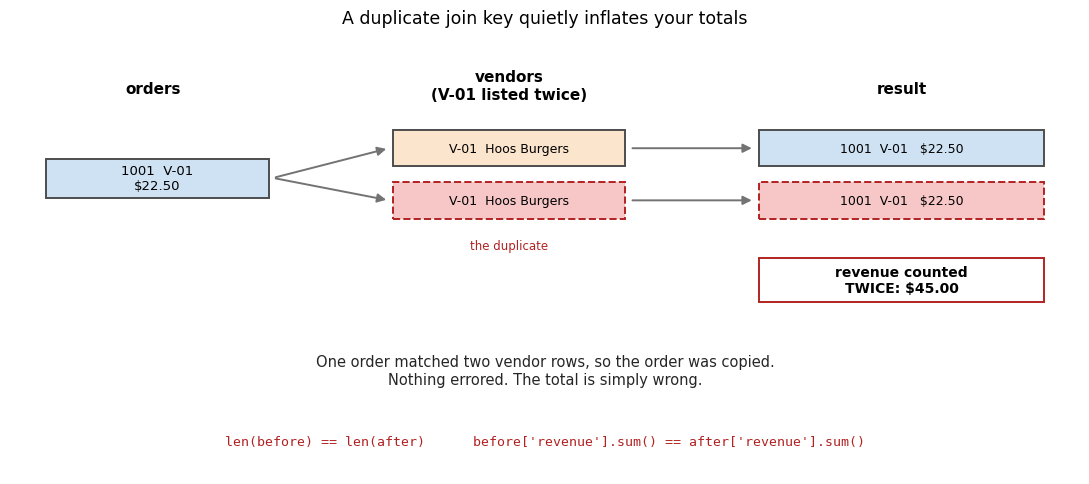

In [20]:
fig, ax = plt.subplots(figsize=(11, 4.8))
panel(ax, 12, 8)
ax.text(1.6, 7.3, 'orders', ha='center', fontsize=11, fontweight='bold')
ax.text(5.6, 7.2, 'vendors\n(V-01 listed twice)', ha='center', fontsize=11,
        fontweight='bold')
ax.text(10.0, 7.3, 'result', ha='center', fontsize=11, fontweight='bold')

box(ax, 0.4, 5.3, 2.5, 0.75, '1001  V-01\n$22.50', face=TINT['Food'], fs=9.5)
box(ax, 4.3, 5.9, 2.6, 0.7, 'V-01  Hoos Burgers', face=TINT['Merch'], fs=9)
box(ax, 4.3, 4.9, 2.6, 0.7, 'V-01  Hoos Burgers', face=TINT['bad'], edge=RED, fs=9,
    dashed=True)
ax.text(5.6, 4.5, 'the duplicate', ha='center', va='top', fontsize=8.5, color=RED)

for ty, face, edge, dash in [(5.9, TINT['Food'], '0.3', False),
                             (4.9, TINT['bad'], RED, True)]:
    arrow(ax, (2.95, 5.68), (4.25, ty + 0.35))
    arrow(ax, (6.95, ty + 0.35), (8.35, ty + 0.35))
    box(ax, 8.4, ty, 3.2, 0.7, '1001  V-01   $22.50', face=face, edge=edge, fs=9,
        dashed=dash)

box(ax, 8.4, 3.3, 3.2, 0.85, 'revenue counted\nTWICE: $45.00', edge=RED, fs=10, bold=True)

ax.text(6.0, 2.3, 'One order matched two vendor rows, so the order was copied.\n'
                  'Nothing errored. The total is simply wrong.',
        ha='center', va='top', fontsize=10.5, color='0.15')
ax.text(6.0, 0.75, "len(before) == len(after)      "
                   "before['revenue'].sum() == after['revenue'].sum()",
        ha='center', va='top', fontsize=9.5, family='monospace', color=RED)
fig.suptitle('A duplicate join key quietly inflates your totals', fontsize=12.5, y=1.0)
fig.tight_layout()
plt.show()

### Practice 1 — units per vendor

Total quantity sold per vendor **name** (not id), highest first. You will need the joined frame.

In [21]:
# TODO

### Practice 2 — revenue by zone

Revenue per zone. Decide what to do with the order whose vendor is unknown, and say what you decided in a comment.

In [22]:
# TODO

### Practice 3 — the SQL translation

Write the Pandas equivalent of:

```sql
SELECT category, SUM(revenue) AS revenue
FROM orders
WHERE qty >= 2
GROUP BY category
HAVING SUM(revenue) > 20
ORDER BY revenue DESC
```

In [23]:
# TODO